# Inteligencia Artificial. Examen Final

Instrucciones:
* Por favor, complete las tareas de este notebook. Deberá enviar este notebook, así como una versión en PDF, a la plataforma Univirtual.
* Para crear el PDF, vaya a Archivo > Descargar como. Puede exportar a PDF mediante Latex, o exportar a HTML y luego imprimir a PDF.
* Añada una explicación clara de su enfoque y una interpretación detallada de sus resultados para cada subpregunta. Para ello, utilice celdas Markdown.

* Añada a continuación los nombres de todos los miembros del equipo.

**Alumno**

Nombre: Gonzalo, Salvador Guevara


Código:20220035B

# 1 Técnicas basadas en regiones para la segmentación de imágenes (4 puntos)


La segmentación de imágenes es el proceso de **asignar una etiqueta a cada píxel en una imagen** de modo que los píxeles con la misma etiqueta compartan ciertas características. Como consecuencia, se producen regiones cuyos píxeles tienen propiedades similares, por ejemplo: intensidad, color, textura o ubicación en la imagen. El resultado de la segmentación de imágenes puede ser:

* un conjunto de segmentos que cubren colectivamente toda la imagen (por ejemplo, umbralización),
* o un conjunto de contornos extraídos de la imagen (por ejemplo, detección de bordes).


<img src="./images/image-segmentation-example.png" width="550"/>

Conceptualmente, existen dos enfoques tradicionales para la segmentación de imágenes:

* **Segmentación de arriba hacia abajo (top-down)**, que considera que los píxeles del mismo objeto en la escena deben estar en la misma región segmentada.
* **Segmentación de abajo hacia arriba (bottom-up)**, que establece que los píxeles similares en la imagen deben estar en la misma región segmentada.


<center><img src="./images/bottom-up_top-down-segmentation.png" width="500"/>Imagen adaptada de <a href="myfootnote1">[1]</a></center>


Aquí ponemos el foco en los enfoques de segmentación de abajo hacia arriba. Los métodos que siguen este enfoque pueden agruparse en:

* **Técnicas basadas en contornos**, que intentan identificar las regiones de la imagen detectando sus contornos.
* **Técnicas basadas en regiones**, que agrupan píxeles que son similares entre sí.

En este notebook, cubriremos ambas familias de técnicas, comenzando con dos métodos populares basados en regiones:

* Expectation-Maximization


## Contexto del problema - Cuantización de color


<img src="./images/color-quantization.jpg" width="800"/>


La cuantización de color es el proceso de reducir el número de colores distintos en una imagen mientras se preserva su apariencia de color lo mejor posible. Tiene muchas aplicaciones, como la compresión de imágenes (por ejemplo, GIFs) o [content-based image retrieval](https://en.wikipedia.org/wiki/Content-based_image_retrieval).


Las técnicas de segmentación de imágenes pueden utilizarse para lograr la cuantización de color, ¡veamos cómo funciona!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats as stats
from ipywidgets import interact, fixed, widgets
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
images_path = './images/'

import sys
sys.path.append("..")
from utils.PlotEllipse import PlotEllipse

## 1.1 K-Means (1.25 puntos)

Como se ha comentado, las técnicas basadas en regiones intentan agrupar los píxeles que son similares. Este problema suele denominarse *problema de agrupamiento*. Different attributes can be used to decide if two pixels are similar or not: intensity, texture, color, pixel location, etc.

El algoritmo **k-means** es una técnica basada en regiones que, dado un conjunto de elementos, crea $K$ clusters a partir de ellos. Por tanto, es una técnica perfecta para abordar la cuantificación del color, ya que nuestro objetivo es reducir la paleta de colores de una imagen a un número fijo de colores $K$.

Pero, **¿cómo funciona el algoritmo k-means** en un dominio de color, donde cada píxel está representado en un espacio n-dimensional? (e.g. las imágenes en escala de grises definen un espacio 1D, mientras que las imágenes RGB un espacio 3D):

1. Elige el número $K$, es decir, el número de clusters en los que se segmentará la imagen (por ejemplo, el número de colores).
2. Coloque $K$ centroides en el espacio de color (por ejemplo, al azar), estos son los centros de las regiones.
3. Cada píxel se asigna al cluster con el centroide más cercano, creando así nuevos clusters.

4. Calcular las nuevas medias de los clusters.

<img src="./images/kmeans-step-2.png" width="400" align="center"/><center><i>Ejemplo de evolución de los centroides a lo largo del tiempo</i></center>$\\[5pt]$

5. Repita los pasos 3 y 4 hasta la convergencia, es decir, algún criterio previamente definido se cumple

<img src="./images/kmeans-step-3.png" width="400" align="center"/><center><i>Resultado Final de la segmentación</i></center>$\\[5pt]$

El procedimiento es el mismo independientemente del número de dimensiones del espacio de trabajo.

Esta técnica presenta una serie de pros y contras:

- **Ventajas**
  - Es sencilla.
  - Se garantiza la convergencia a un mínimo local (pero no se garantiza alcanzar el mínimo global).
- **Desventajas:**
  - Alto consumo de memoria.
  - La K debe ser fija.
  - Sensible a la selección de la inicialización (posición inicial de centroides).
  - Sensible a outliers.
  - Se asumen clusters circulares en el espacio de características (debido al uso de la distancia euclidiana).
### K-means ejemplo de juguete

Por suerte para nosotros, OpenCV define un método que realiza k-means: [`cv2.kmeans()`](https://docs.opencv.org/2.4/modules/core/doc/clustering.html). Veamos un ejemplo de k-means 1D de juguete para familiarizarnos con él. La siguiente función, `binarize_kmeans()`, binariza una `imagen` de entrada ejecutando el algoritmo K-means, donde `it` establece el número máximo de iteraciones (representa el criterio de parada/convergencia).

In [ ]:
def binarize_kmeans(image,it):
    """ Binarize an image using k-means.

        Args:
            image: Input image
            it: K-means iteration
    """


    # Set random seed for centroids
    cv2.setRNGSeed(124)

    # Flatten image
    flattened_img = image.reshape((-1,1))
    flattened_img = np.float32(flattened_img)

    #Set epsilon
    epsilon = 0.2

    # Estabish stopping criteria (either `it` iterations or moving less than `epsilon`)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, it, epsilon)

    # Set K parameter (2 for thresholding)
    K = 2

    # Call kmeans using random initial position for centroids
    _,label,center=cv2.kmeans(flattened_img,K,None,criteria,it,cv2.KMEANS_RANDOM_CENTERS)

    # Colour resultant labels
    center = np.uint8(center)
    flattened_img = center[label.flatten()]

    # Reshape vector image to original shape
    binarized = flattened_img.reshape((image.shape))

    # Show resultant image
    plt.subplot(2,1,1)
    plt.title("Original image")
    plt.imshow(binarized, cmap='gray',vmin=0,vmax=255)

    # Show how original histogram have been segmented
    plt.subplot(2,1,2)
    plt.title("Segmented histogram")
    plt.hist([image[binarized==center[0]].ravel(), image[binarized==center[1]].ravel()],256,[0,256], color=["black","gray"],stacked="true")

Nótese que el criterio de parada puede ser o bien si se alcanza un número máximo de iteraciones, o bien si el centroide se mueve menos que un cierto valor de **epsión** en una iteración.

Como puede ver, [`cv2.kmeans()`](https://docs.opencv.org/2.4/modules/core/doc/clustering.html) devuelve dos argumentos relevantes:

- label: Matriz de enteros que almacena el índice del cluster para cada muestra.
- center: Matriz que contiene los centroides de los clusters (cada fila representa un centroide diferente).

A continuación se proporciona un código interactivo para que puedas jugar con `cv2.kmeans()` llamándolo con diferentes valores de `it`. Después de probarlo **se te pide que expliques** qué está haciendo `cv2.kmeans()` en cada iteración.

*Como puedes ver, si k=2 en una imagen en escala de grises, es un método de binarización que no necesita fijar un umbral manual.
Nótese que para espacios 1D y no para imágenes de alta resolución, ¡K-means es muy rápido! (sólo necesita unas pocas iteraciones para converger). ¿Qué ocurre si k-means se aplica con imágenes en color (espacio 3D) para obtener la cuantificación del color?  

Ahora que ya sabes cómo funciona k-means, puedes responder experimentalmente a esta pregunta.  
###  **<span style="color:green"><b><i>Problema 5.1: Jugando con K-means</i></b></span>**

Escribe un script que:
- aplique k-means a `malaga.png` con diferentes valores para $K$: $K=4$, $K=8$ y $K=16$,
- muestre, en un subplot de $2\times2$, las 3 imágenes resultantes junto con la de entrada.
<font color='blue'>**Salida Esperada:**  </font>

<img src="images/exercise1.png" width="800"/>

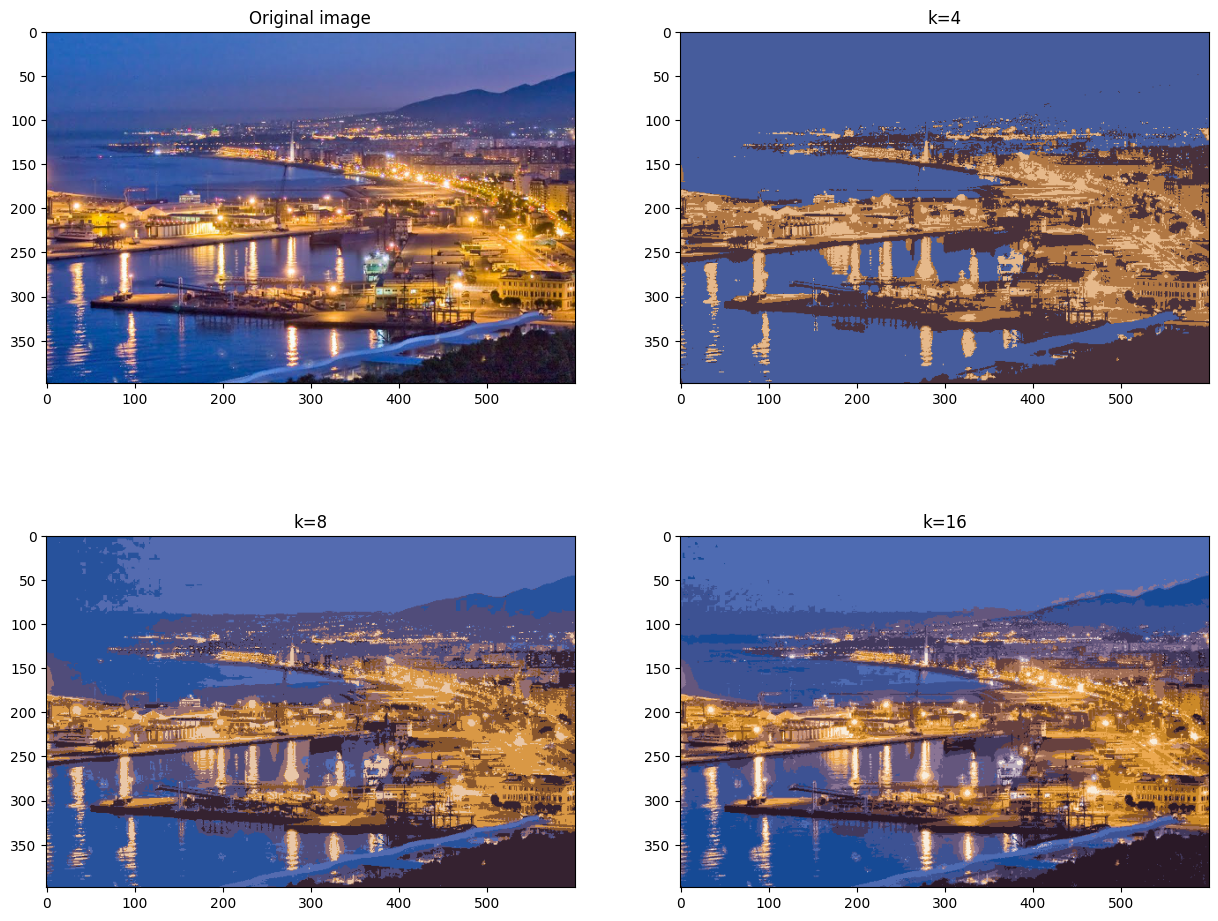

In [ ]:
# Problema 5.1
matplotlib.rcParams['figure.figsize'] = (15.0, 12.0)
cv2.setRNGSeed(124)

image = cv2.cvtColor(cv2.imread(images_path + "malaga.png"), cv2.COLOR_BGR2RGB)
samples = np.float32(image.reshape((-1, 3)))

it = 10
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, it, 0.2)

plt.subplot(2, 2, 1)
plt.title("Original image")
plt.imshow(image)

for pos, K in zip((2, 3, 4), (4, 8, 16)):
    _, labels, centers = cv2.kmeans(samples, K, None, criteria, it, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    quantized = centers[labels.flatten()].reshape(image.shape)
    plt.subplot(2, 2, pos)
    plt.title("k=" + str(K))
    plt.imshow(quantized)

**Enfoque.** Aplano la imagen a una matriz de píxeles de tres columnas (R, G, B) y llamo a `cv2.kmeans` para K=4, 8 y 16 reutilizando el mismo criterio de parada. Cada resultado se reconstruye sustituyendo el píxel por el centroide de su clúster, es decir, por uno de los K colores de la paleta.

**Interpretación.** Con K=4 la paleta es demasiado pobre: el cielo y el mar caen en un único azul y se pierden los tonos intermedios, apareciendo zonas planas. Al subir a 8 y 16 se recuperan los degradados y las luces del puerto; con 16 colores el resultado es prácticamente indistinguible del original a simple vista. Cada vez que se dobla K mejora el detalle, pero con rendimientos decrecientes.

Ahora, **responde a las siguientes preguntas**:

- ¿Qué número de iteraciones máximas utilizaste? ¿Por qué?

  Fijé el máximo en 10 iteraciones. En un espacio de tres dimensiones (RGB) k-means converge en pocos pasos: los centroides se estabilizan y el criterio de epsilon (0.2) suele cortar el bucle antes de agotar el límite. Subir el máximo no cambia el resultado, solo añade cálculo, y con menos de 8 los centroides aún se mueven de forma apreciable. Diez iteraciones dan un resultado estable para K=4, 8 y 16.

- ¿Cómo sería posible comprimir estas imágenes? *Nota: considera que un píxel necesita 3 bytes para ser representado, 8 bits por banda.*

  Pasando de color verdadero a color indexado. En lugar de guardar 3 bytes por píxel (24 bits), se almacena una paleta de K colores (3 bytes cada uno) y, por cada píxel, solo el índice de su color: log2(K) bits, redondeado al alza. Para malaga.png (399×600 = 239 400 píxeles):

  | K | bits/píxel | Tamaño aprox. | Factor |
  |---|---|---|---|
  | original | 24 | 718 200 B | 1× |
  | 4  | 2 | 59 862 B  | 12× |
  | 8  | 3 | 89 799 B  | 8×  |
  | 16 | 4 | 119 748 B | 6×  |

  El factor de compresión, despreciando la paleta, es 24 / log2(K). Es el esquema que usan GIF y PNG en modo indexado.

###  **<span style="color:green"><b><i>ASIGNACIÓN EXTRA: Analizar los tiempos de ejecución</i></b></span>**

En este ejercicio se le pide que compare el tiempo de ejecución de K-means en una imagen en escala de grises, con K-means en una imagen RGB. Usa la imagen `malaga.png` para esta tarea, y usa el mismo número de clusters y criterios para ambas imágenes, la de escala de grises y la RGB.

*Sugerencia: [cómo medir el tiempo de ejecución en Python](https://stackoverflow.com/questions/14452145/how-to-measure-time-taken-between-lines-of-code-in-python)*

In [ ]:
import time

gray = cv2.imread(images_path + "malaga.png", 0)
color = cv2.cvtColor(cv2.imread(images_path + "malaga.png"), cv2.COLOR_BGR2RGB)

K = 8
it = 10
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, it, 0.2)

cv2.setRNGSeed(124)
start = time.time()
cv2.kmeans(np.float32(gray.reshape((-1, 1))), K, None, criteria, it, cv2.KMEANS_RANDOM_CENTERS)
gray_time = time.time() - start

cv2.setRNGSeed(124)
start = time.time()
cv2.kmeans(np.float32(color.reshape((-1, 3))), K, None, criteria, it, cv2.KMEANS_RANDOM_CENTERS)
color_time = time.time() - start

print("Grayscale (1D): %.4f s" % gray_time)
print("RGB (3D):       %.4f s" % color_time)

Grayscale (1D): 0.4497 s
RGB (3D):       0.4237 s


**Interpretación.** El coste de k-means depende del número de muestras y de la dimensión del espacio. Ambas imágenes tienen el mismo número de píxeles, pero la de grises trabaja en 1D y la de color en 3D, así que la versión RGB calcula distancias y actualiza centroides con tres componentes en lugar de una. Por eso la RGB es más lenta, aunque la diferencia es moderada porque lo que más pesa (el número de píxeles) es idéntico en los dos casos.

## 1.2 Expectation-Maximization (EM): (2.75 puntos)

**Expectation-Maximization (EM)** es la generalización del algoritmo K-means, donde cada clúster está representado por una distribución Gaussiana, parametrizada por una media y una matriz de covarianza, en lugar de solo un centroide. Es un *clustering suave* ya que no toma decisiones *duras* sobre si un píxel pertenece o no a un clúster, sino que calcula la probabilidad de que ese píxel pertenezca a cada clúster $C_j$, that is, $p(x|C_j) \sim N(\mu_j,\Sigma_j)$.  Esto implica que en cada iteración del algoritmo no solo se refina la media de cada clúster (como en K-means), sino también sus matrices de covarianza.

Antes de entrar en detalle sobre la teoría detrás de EM, vale la pena ver cómo se desempeña en el problema de la placa del auto. OpenCV proporciona una clase que implementa la funcionalidad necesaria para aplicar segmentación EM a una imagen, llamada [cv2.ml.EM](https://docs.opencv.org/3.4/d1/dfb/classcv_1_1ml_1_1EM.html). Todos los métodos y parámetros están completamente detallados en la documentación, por lo que es una buena idea echarle un vistazo.


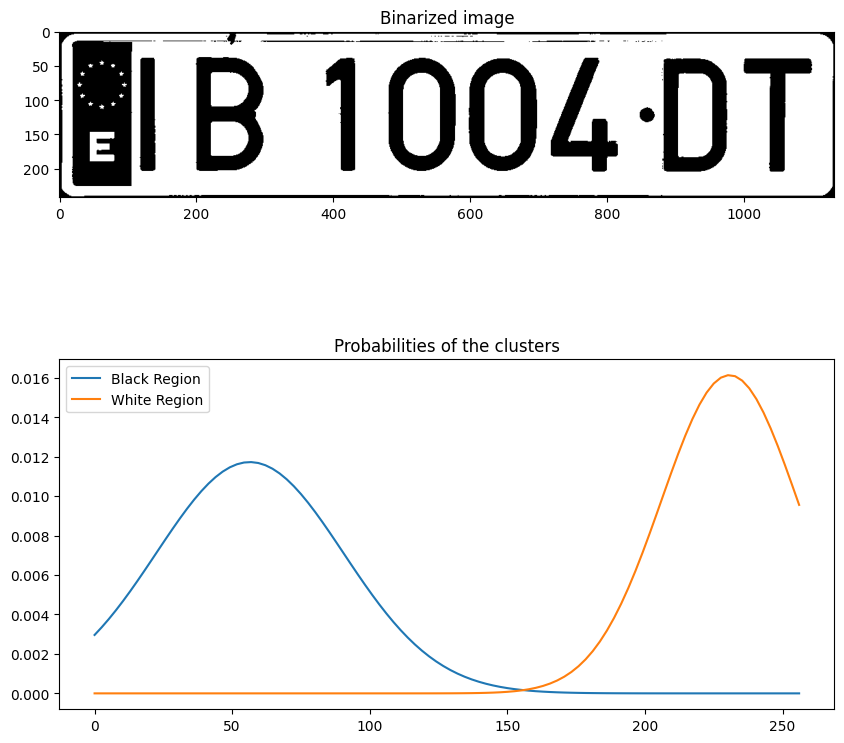

In [ ]:
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
cv2.setRNGSeed(5)

# Define parameters
n_clusters = 2
covariance_type = 0 # 0: covariance matrix spherical. 1: covariance matrix diagonal. 2: covariance matrix generic
n_iter = 10
epsilon = 0.2

# Create EM empty object
em = cv2.ml.EM_create()

# Set parameters
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, n_iter, epsilon)
em.setClustersNumber(n_clusters)
em.setCovarianceMatrixType(covariance_type)
em.setTermCriteria(criteria)

# Read grayscale image
image = cv2.imread(images_path + "plate.jpg",0)

# Flatten image
flattened_img = image.reshape((-1,1))
flattened_img = np.float32(flattened_img)

# Apply EM
_, _, labels, _ = em.trainEM(flattened_img)

# Reshape labels to image size (binarization)
binarized = labels.reshape((image.shape))

# Show original image
plt.subplot(2,1,1)
plt.title("Binarized image")
plt.imshow(binarized, cmap="gray")

# --------------- Gaussian visualization ---------------

plt.subplot(2,1,2)
plt.title("Probabilities of the clusters")

# Get means and covs (for grayscale 1D both)
means = em.getMeans()
covs = em.getCovs()

# Get standard deviation as numPy array
sigmas = np.sqrt(covs)
sigmas = sigmas[:,0,0]

# Cast list to numPy array
means = np.array(means)[:,0]

# Plot Gaussians
x = np.linspace(0, 256, 100)
plt.plot(x, stats.norm.pdf(x, loc = means[0], scale = sigmas[0]))
plt.plot(x, stats.norm.pdf(x, loc = means[1], scale = sigmas[1]))
plt.legend(['Black Region', 'White Region'])

plt.show()

Como puedes ver, aunque en OpenCV **k-means** está implementado como un método y **EM** como una clase, ambos operan de forma similar. En el ejemplo anterior, estamos segmentando una placa de automóvil en dos clústeres, y **cada clúster está definido por una distribución Gaussiana** (una distribución Gaussiana para la región negra y otra para la región blanca). Esta es la base de EM, pero **¿cómo funciona?**

EM es un algoritmo iterativo que se divide en dos pasos principales:

* Primero, **inicializa la media y la matriz de covarianza de cada uno de los \$K\$ clústeres**. Típicamente, se eligen al azar (\$\mu\_j\$, \$\Sigma\_j\$) y \$P(C\_j)\$ (probabilidad a priori) para cada clúster \$j\$.
* Luego, se mantiene iterando realizando los pasos de Expectación-Maximización hasta que se cumpla algún criterio de parada (por ejemplo, cuando no ocurre ningún cambio en una iteración completa):

  1. **Paso de Expectación:** calcular las probabilidades de que cada punto pertenezca a cada clúster, es decir, \$p(C\_j|x\_i), \forall i \in \text{data}\$:

  $$
  P(C_j|x_i)=\frac{p(x_i|C_j)p(C_j)}{p(x_i)}=\frac{p(x_i|C_j)p(C_j)}{\sum_i p(x_i|C_j)p(C_j)}
  $$

  Se asigna \$x\_i\$ al clúster \$C\_j\$ con la mayor probabilidad \$P(C\_j|x\_i)\$.
  
  2\. **Paso de Maximización:** se reestiman los parámetros de los clústeres ((\$\mu\_j\$, \$\Sigma\_j\$) y \$p(C\_j)\$) para cada clúster \$j\$ conociendo los resultados del paso de expectación, lo que también se conoce como *Estimación de Máxima Verosimilitud (MLE)*:

  $$
  \mu_j=\frac{\sum_i p(C_j|x_i)x_i}{\sum_i p(C_j|x_i)} \\
  \Sigma_j = \frac{\sum_i p(C_j|x_i)(x_i-\mu_j)(x_i-\mu_j)^T}{\sum_i p(C_j|x_i)} \\
  p(C_j)=\sum_i p(C_j|x_i)p(x_i)=\frac{\sum_i p(C_j|x_i)}{N}
  $$

  *Nota que si no se dispone de otra información, se considera que las probabilidades a priori son igualmente probables.*


<img src="./images/em.gif" width="400" align="center">
<center><i>Ejemplo de una ejecución del algoritmo EM con dos clústeres, mostrando la evolución de sus distribuciones Gaussianas asociadas.</i></center>


¿No te recuerda al algoritmo K-means? **¿Cuál es la diferencia entre ellos?**

La principal diferencia es que **K-means utiliza la distancia euclidiana** para medir qué tan cerca está un punto de un clúster. En EM se utiliza una distancia en la que **cada dimensión se pondera** según la **matriz de covarianza** de cada clúster, lo que se conoce como **distancia de Mahalanobis**. Además, en K-means un punto de datos **pertenece o no** a un clúster, mientras que en EM un punto de datos tiene una **probabilidad mayor o menor** de pertenecer a un clúster. La siguiente tabla resume otras diferencias:


<table width="500px">
    <tr>
        <td style="text-align:center;"></td>
        <td style="text-align:center;"><b>K-means</b></td>
        <td style="text-align:center;"><b>EM</b></td>
    </tr>
    <tr>
        <td style="text-align:center;"><b>Representación del clúster</b></td>
        <td style="text-align:center;">Media</td>
        <td style="text-align:center;">Media y (co)varianza</td>
    </tr>
    <tr>
        <td style="text-align:center;"><b>Inicialización del clúster</b></td>
        <td style="text-align:center;">Selección aleatoria de K medias</td>
        <td style="text-align:center;">Inicialización de K distribuciones Gaussianas <br />($\mu_j$, $\Sigma_j$) y $P(C_j)$</td>
    </tr>
    <tr>
        <td style="text-align:center;"><b>Expectación:</b> <br /> Estimar el clúster de cada dato</td>
        <td style="text-align:center;">Asignar cada punto a la media más cercana</td>
        <td style="text-align:center;">Calcular $P(C_j|x_i)$</td>
    </tr>
    <tr>
        <td style="text-align:center;"><b>Maximización:</b> <br /> Reestimar los parámetros del clúster</td>
        <td style="text-align:center;">Calcular medias de los clústeres actuales</td>
        <td style="text-align:center;">Calcular nuevos ($\mu_j$, $\Sigma_j$) y $P(C_j)$ para cada clúster $j$</td>
    </tr>
</table>


Si aún tienes curiosidad sobre EM, puedes encontrar [aquí](https://www.youtube.com/watch?v=REypj2sy_5U) una explicación más detallada.


#### <font color="orange">Cápsula OpenCV</font>

Volviendo al código, al trabajar con EM debemos especificar un tipo de matriz de covarianza utilizando [`em.setCovarianceMatrixType()`](https://docs.opencv.org/3.4/d1/dfb/classcv_1_1ml_1_1EM.html#a8b383c62697eac9a972931674790f6cd). Además, cuando aplicas [`em.trainEM()`](https://docs.opencv.org/3.4/d1/dfb/classcv_1_1ml_1_1EM.html#a5a6a7badbc0c85a8c9fa50a41bf1bcd2), este no devuelve el centroide de los clústeres; es posible obtenerlos llamando a [`em.getMeans()`](https://docs.opencv.org/3.4/d1/dfb/classcv_1_1ml_1_1EM.html#acec62dd55c06711c81d741c2d96603d1).


### **<span style="color:green"><b><i>TAREA 2: Cuantización de color con el espacio de color YCrCb</i></b></span>**

En el siguiente ejemplo, la cuantización de color se realiza utilizando el espacio de color YCrCb (más información sobre este espacio en el apéndice 2) en lugar de RGB. De este modo, la cuantización de color se aplica solo a las dos bandas de color, omitiendo la banda en escala de grises. ¡Veamos cómo funciona!

**¿Qué hacer?** Entender y probar el siguiente código.


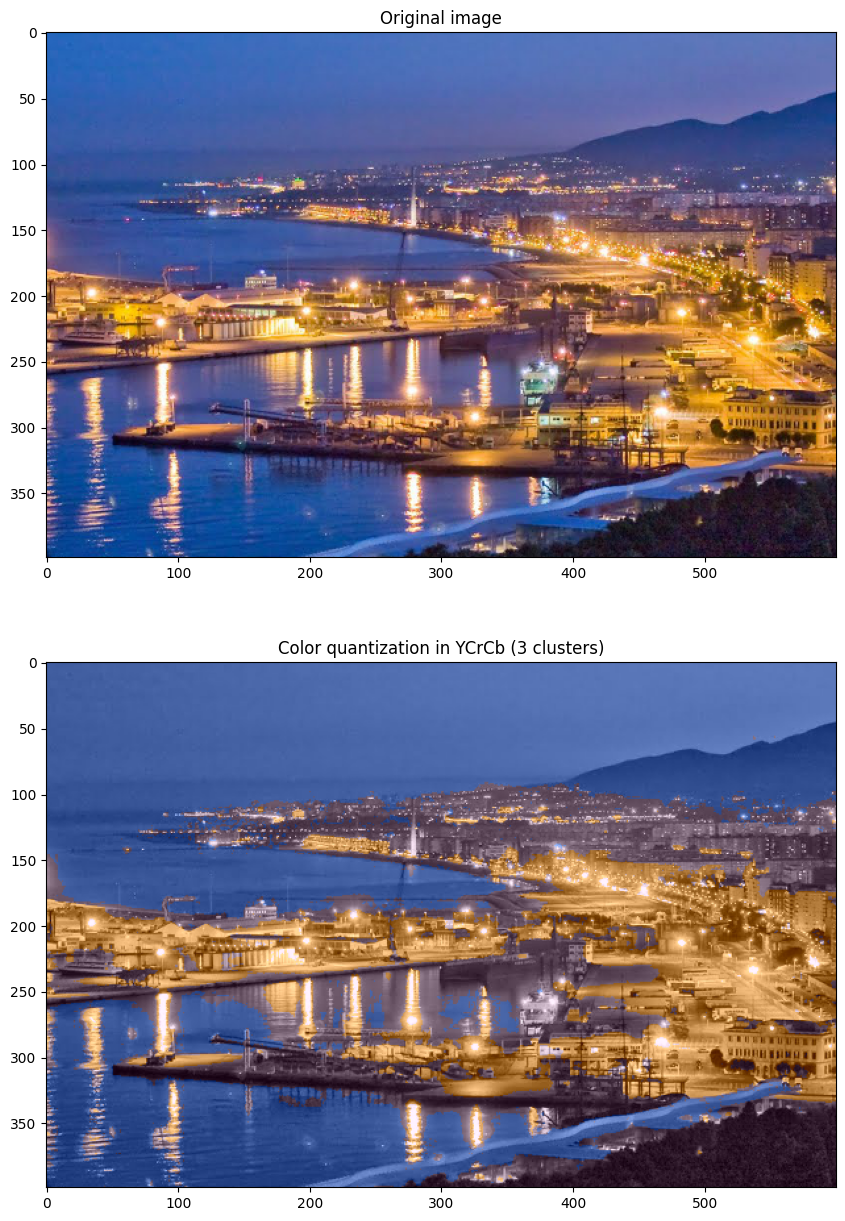

In [ ]:
# Assignment 2
matplotlib.rcParams['figure.figsize'] = (15.0, 15.0)
cv2.setRNGSeed(5)

n_clusters = 3  # Don't modify this parameter for this exercise
covariance_type = 2  # 0: spherical, 1: diagonal, 2: full
n_iter = 10
epsilon = 0.2

em = cv2.ml.EM_create()
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, n_iter, epsilon)
em.setClustersNumber(n_clusters)
em.setCovarianceMatrixType(covariance_type)
em.setTermCriteria(criteria)

image = cv2.cvtColor(cv2.imread(images_path + "malaga.png"), cv2.COLOR_BGR2YCrCb)
color_bands = image[:, :, 1:]
samples = np.float32(color_bands.reshape((-1, 2)))

_, _, labels, _ = em.trainEM(samples)

centers = np.uint8(em.getMeans())
res = centers[labels.flatten()]
color_bands = res.reshape(color_bands.shape)

quantized = np.dstack((image[:, :, 0], color_bands)).astype(np.uint8)
quantized = cv2.cvtColor(quantized, cv2.COLOR_YCrCb2RGB)

original = cv2.cvtColor(cv2.imread(images_path + "malaga.png"), cv2.COLOR_BGR2RGB)
plt.subplot(2, 1, 1)
plt.title("Original image")
plt.imshow(original)
plt.subplot(2, 1, 2)
plt.title("Color quantization in YCrCb (3 clusters)")
plt.imshow(quantized)

**Enfoque.** Convierto la imagen a YCrCb y aplico EM únicamente sobre las dos bandas de color (Cr, Cb), dejando la luminancia Y intacta. Tras el ajuste, cada píxel de color se sustituye por la media de su clúster; luego vuelvo a unir la Y original con las bandas cuantizadas y reconvierto a RGB.

**Interpretación.** Con solo 3 clústeres la imagen conserva casi todo su aspecto: el detalle vive en Y, que no se toca, y lo único que se simplifica es la tonalidad. Es un resultado mucho mejor que cuantizar a 3 colores en RGB.

### <font color="blue"><b><i>Reflexionando sobre ello (2)</i></b></font>

Una vez que hayas entendido el código anterior, **responde las siguientes preguntas:**

* ¿Por qué los resultados obtenidos son tan buenos usando solo 3 clústeres?

  Porque en YCrCb la cuantización afecta solo a las dos bandas de crominancia (Cr, Cb) y la luminancia Y se conserva intacta. El detalle estructural de la escena (bordes, texturas, luces) está casi por completo en Y, y el ojo humano es mucho más sensible a la luminancia que al color. Al no tocar Y, aunque el color se reduzca a 3 grupos la imagen sigue viéndose nítida: lo único que se simplifica es la tonalidad. En RGB esto no pasa porque la intensidad está repartida entre las tres bandas, así que reducir a 3 colores degrada también el detalle.

* ¿Qué compresión sería mejor en términos de espacio en memoria: una compresión a 16 colores en una imagen RGB o una compresión a 4 colores en una imagen YCrCb?

  Comparando el coste por píxel:
  - 16 colores en RGB: índice de 4 bits/píxel más una paleta pequeña ≈ 0.5 bytes/píxel.
  - 4 colores en YCrCb: la banda Y se guarda completa (1 byte/píxel) y solo las dos bandas de color se cuantizan a 4 (2 bits/píxel) ≈ 1.25 bytes/píxel.

  En memoria gana la cuantización a 16 colores en RGB (≈0.5 frente a ≈1.25 bytes/píxel), porque YCrCb paga el coste de conservar la luminancia completa. El contraste es el esperado: RGB ocupa menos pero se ve peor, mientras que YCrCb ocupa más y mantiene la calidad, precisamente porque no toca Y.

### Profundizando en las matrices de covarianza

Existen 3 tipos de matrices de covarianza: **covarianzas esféricas**, **covarianzas diagonales** o **covarianzas completas**:


<img src="./images/ellipses.png" width="700" align="center">




### **<span style="color:green"><b><i>TAREA 3: Visualizando los clústeres con EM</i></b></span>**

A continuación, tienes un código para visualizar los clústeres en el espacio de color YCrCb utilizando EM.

**¿Qué hacer?** Ejecuta el ejemplo anterior modificando el tipo de covarianza en el algoritmo EM y visualiza los cambios utilizando el siguiente código.


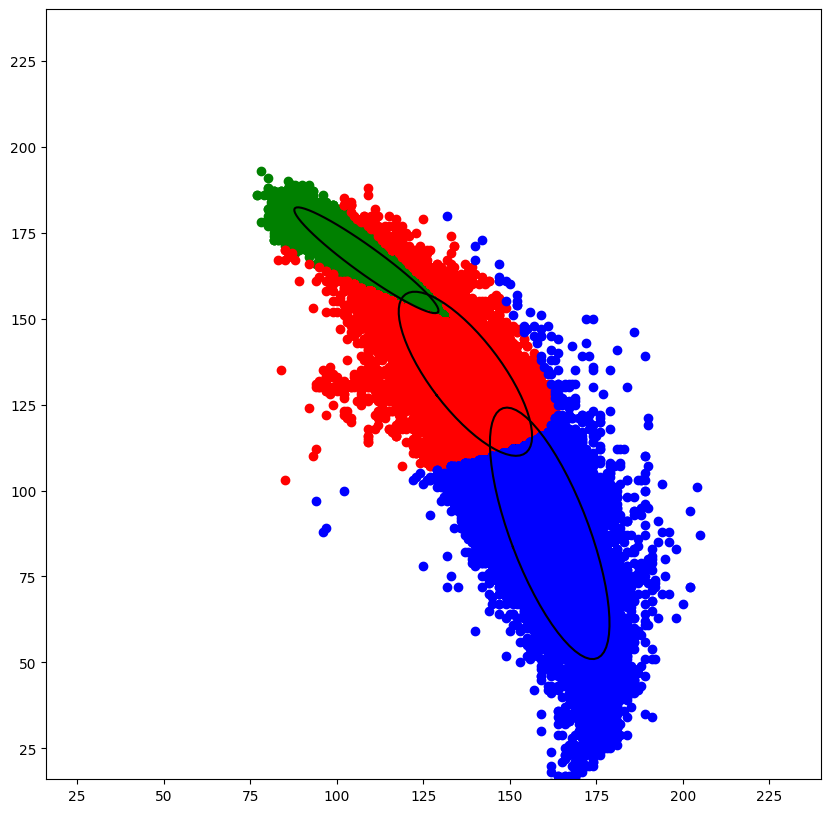

In [ ]:
# Assignment 3
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)

# Get means (2D) and covariance matrices (2x2)
means = np.array(em.getMeans())
covs = np.array(em.getCovs())

# Create figure
fig, ax = plt.subplots()
plt.axis([16, 240, 16, 240])

# Get points contained in each cluster
cluster_1 = np.any(color_bands == np.unique(res,axis=0)[0,:],axis=2)
cluster_2 = np.any(color_bands == np.unique(res,axis=0)[1,:],axis=2)
cluster_3 = np.any(color_bands == np.unique(res,axis=0)[2,:],axis=2)
cluster_1 = image[cluster_1]
cluster_2 = image[cluster_2]
cluster_3 = image[cluster_3]

# Plot them
plt.plot(cluster_1[:,1],cluster_1[:,2],'go')
plt.plot(cluster_2[:,1],cluster_2[:,2],'ro')
plt.plot(cluster_3[:,1],cluster_3[:,2],'bo')

# Plot ellipses representing covariance matrices
PlotEllipse(fig, ax, np.vstack(means[0,:]), covs[0,:,:], 2, color='black')
PlotEllipse(fig, ax, np.vstack(means[1,:]), covs[1,:,:], 2, color='black')
PlotEllipse(fig, ax, np.vstack(means[2,:]), covs[2,:,:], 2, color='black')

fig.canvas.draw()

**Interpretación.** Cada punto es un píxel proyectado en el plano Cr-Cb y cada color corresponde a un clúster. Las elipses son las gaussianas ajustadas por EM a dos desviaciones típicas. Con covarianza completa las elipses se inclinan y se alargan siguiendo la nube de puntos, algo que una covarianza esférica (círculos) no podría capturar. Se aprecia que los clústeres están correlacionados en Cr y Cb, por eso la orientación de las elipses no es paralela a los ejes.

### <font color="blue"><b><i>Reflexionando sobre ello (3)</i></b></font>

**Responde las siguientes preguntas** sobre cómo funciona el clustering en EM:

* ¿Cuáles son las diferencias entre cada tipo de covarianza?

  - **Esférica:** la matriz es σ²I. Misma varianza en todas las direcciones y sin correlación, así que los clústeres son círculos del mismo radio en cada eje. Es la que menos parámetros tiene.
  - **Diagonal:** matriz diagonal, con una varianza distinta por eje pero ceros fuera de la diagonal. Da elipses alineadas con los ejes: pueden estirarse en horizontal o vertical, pero no girar.
  - **Completa (generic):** matriz simétrica llena, con varianzas y covarianzas. Permite elipses de cualquier orientación, capaces de seguir clústeres alargados e inclinados. Es la más flexible y la que mejor ajusta datos correlacionados, a costa de más parámetros y mayor riesgo de sobreajuste.

* ¿Qué tipo de covarianza hace que EM sea equivalente a k-means?

  La esférica. Cuando todos los clústeres comparten una covarianza isótropa (σ²I), la distancia de Mahalanobis se reduce a la distancia euclídea y asignar cada punto a la gaussiana más probable equivale a asignarlo al centroide más cercano. Si además se fuerza la asignación dura (cada punto a un solo clúster), EM se convierte exactamente en k-means.


### **<span style="color:green"><b><i>TAREA 4: Aplicando EM considerando diferentes espacios de color</i></b></span>**

¡Es hora de demostrar lo que has aprendido sobre **EM** y **espacios de color**!

**¿Cuál es tu tarea?** Se te pide que **compares la cuantización de color en un espacio de color RGB y en un espacio de color YCrCb**.

Para ello:

* aplica el algoritmo Expectation-Maximization a `malaga.png` utilizando 4 clústeres (colores) tanto en la imagen en espacio RGB como en la imagen en espacio YCrCb,
* y muestra ambos resultados junto con la imagen original.


<font color='blue'>**Salida esperada:**  </font>

<img src="images/exercise2.png" width="800"/>

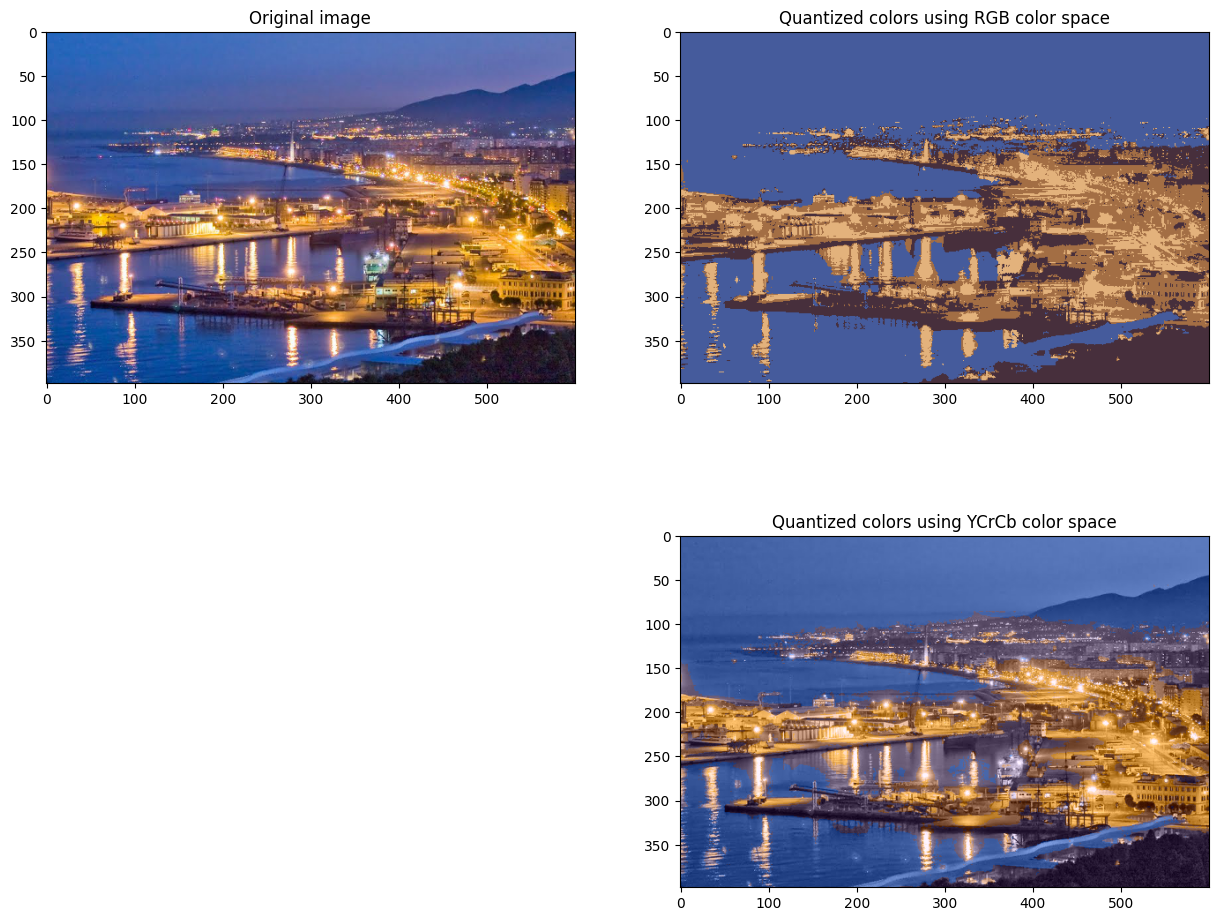

In [ ]:
# Assignment 4
matplotlib.rcParams['figure.figsize'] = (15.0, 12.0)
cv2.setRNGSeed(5)

n_clusters = 4
covariance_type = 2  # 0: covariance matrix spherical. 1: covariance matrix diagonal. 2: covariance matrix generic
n_iter = 10
epsilon = 0.2

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, n_iter, epsilon)
em_rgb = cv2.ml.EM_create()
em_ycrcb = cv2.ml.EM_create()
for em in (em_rgb, em_ycrcb):
    em.setClustersNumber(n_clusters)
    em.setCovarianceMatrixType(covariance_type)
    em.setTermCriteria(criteria)

bgr = cv2.imread(images_path + "malaga.png")
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
ycrcb = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)

rgb_samples = np.float32(rgb.reshape((-1, 3)))
bands = ycrcb[:, :, 1:]
band_samples = np.float32(bands.reshape((-1, 2)))

_, _, labels_rgb, _ = em_rgb.trainEM(rgb_samples)
centers_rgb = np.uint8(em_rgb.getMeans())
quant_rgb = centers_rgb[labels_rgb.flatten()].reshape(rgb.shape)

_, _, labels_ycrcb, _ = em_ycrcb.trainEM(band_samples)
centers_ycrcb = np.uint8(em_ycrcb.getMeans())
quant_bands = centers_ycrcb[labels_ycrcb.flatten()].reshape(bands.shape)
quant_ycrcb = np.dstack((ycrcb[:, :, 0], quant_bands)).astype(np.uint8)
quant_ycrcb = cv2.cvtColor(quant_ycrcb, cv2.COLOR_YCrCb2RGB)

plt.subplot(2, 2, 1)
plt.title("Original image")
plt.imshow(rgb)
plt.subplot(2, 2, 2)
plt.title("Quantized colors using RGB color space")
plt.imshow(quant_rgb)
plt.subplot(2, 2, 4)
plt.title("Quantized colors using YCrCb color space")
plt.imshow(quant_ycrcb)

**Interpretación.** Con 4 colores la diferencia entre espacios es evidente. En RGB la intensidad y el color están mezclados en las tres bandas, así que cuantizar deja la imagen en cuatro tonos planos y elimina el relieve del puerto y el degradado del cielo. En YCrCb solo se cuantizan Cr y Cb y la luminancia Y se mantiene completa, de modo que con los mismos 4 grupos de color la escena conserva todo su detalle y solo se reduce la paleta cromática. A igualdad de número de clústeres, YCrCb da un resultado claramente superior.

## Conclusión

¡Felicidades por haber completado este trabajo! Has aprendido:

* cómo funciona el clustering k-means y cómo utilizarlo,
* cómo se desempeña el algoritmo EM y cómo emplearlo,
* cómo realizar cuantización de color y la importancia de los espacios de color en este contexto, y
* algunos conceptos básicos sobre compresión de imágenes.

### Extra

Has utilizado YCrCb en este notebook porque ya estabas familiarizado con él. La verdad es que, en temas de cuantización de color, [Lab color space](https://en.wikipedia.org/wiki/CIELAB_color_space) es comúnmente utilizado.

Busca información en internet sobre el espacio de color Lab y luego  **responde las siguientes preguntas:**:

- **¿Cómo funciona el espacio de color Lab?**

  CIELAB describe cada color con tres componentes: L* (luminosidad, de 0 negro a 100 blanco), a* (eje verde-rojo) y b* (eje azul-amarillo). Separa la luminosidad del color, igual que YCrCb, pero se deriva del espacio CIE XYZ mediante una transformación no lineal (raíz cúbica) pensada para imitar la respuesta del ojo. Es independiente del dispositivo y, sobre todo, aproximadamente uniforme desde el punto de vista perceptual: la distancia euclídea entre dos colores (ΔE) se corresponde con la diferencia que percibe una persona.

- **¿Por qué se utiliza típicamente para la cuantización de color?**

  Porque k-means y EM agrupan usando distancia euclídea. Al ser Lab perceptualmente uniforme, esa distancia equivale a diferencia de color percibida, de modo que los clústeres minimizan el error visible de la paleta. Con el mismo número de colores el resultado se ve mejor que cuantizando en RGB, donde distancias iguales no implican diferencias percibidas iguales. Por eso Lab es el espacio habitual para esta tarea.

# 2. Tarea: Clasificación de Imágenes (6 puntos)

En este ejercicio práctico resolverás un problema de clasificación de imágenes utilizando modelos profundos.

Los objetivos de esta tarea son:

* Desarrollar destreza en el uso de Keras para entrenar redes neuronales (NNs).
* Poner en práctica conocimientos generales de Machine Learning para optimizar los parámetros y la arquitectura de una red neuronal densa de avance directo (ffNN), en el contexto de un problema de visión por computadora.
* Utilizar redes neuronales especialmente concebidas para analizar imágenes. Diseñar y optimizar los parámetros de una red neuronal convolucional (cNN).
* Mejorar el rendimiento de una red neuronal mediante regularización y procesamiento de los datos a través de la red.


## A) Dense feed forward model (1.25 puntos)

Diseña y entrena una **ffNN** que resuelva el problema de clasificación planteado en la base de datos **Cifar-10**.

Como punto de partida en este proyecto, puedes utilizar el modelo proporcionado en los materiales del curso.

Debes mejorar los resultados obtenidos en los archivos de configuración de la red inicial. Para ello, debes decidir sobre:

* El número de capas y el número de unidades en cada capa.
* El algoritmo de optimización y los parámetros para entrenar la red.
* Revisar la evolución de estos parámetros durante la optimización y decidir cuándo detener el entrenamiento.


In [1]:
# Load CIFAR-10 data set
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3498s 21us/step


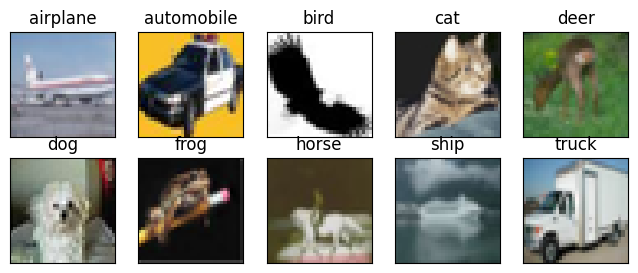

In [2]:
# Show examples from each class
import numpy as np
import matplotlib.pyplot as plt

num_classes = len(np.unique(y_train))
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
fig = plt.figure(figsize=(8,3))
for i in range(num_classes):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    ax.set_title(class_names[i])
    idx = np.where(y_train[:]==i)[0]
    features_idx = X_train[idx,::]
    rnd_img = np.random.randint(features_idx.shape[0])
    im = np.transpose(features_idx[rnd_img,::], (0, 1, 2))
    plt.imshow(im)
plt.show()

In [3]:
# Data pre-processing
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255.0
X_test /= 255.0

from tensorflow.keras.utils import to_categorical
Y_train = to_categorical(y_train, num_classes)
Y_test = to_categorical(y_test, num_classes)

In [4]:
def plot_model_history(model_history):
    fig, axs = plt.subplots(1,2,figsize=(15,5))
    # Summarize history for accuracy
    axs[0].plot(range(1,len(model_history.history['accuracy'])+1),model_history.history['accuracy'])
    axs[0].plot(range(1,len(model_history.history['val_accuracy'])+1),model_history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    #axs[0].set_xticks(np.arange(1,len(model_history.history['accuracy'])+1),len(model_history.history['accuracy'])/10)
    axs[0].set_xticks(np.arange(1,len(model_history.history['accuracy'])+1))
    axs[0].legend(['train', 'val'], loc='best')
    # summarize history for loss
    axs[1].plot(range(1,len(model_history.history['loss'])+1),model_history.history['loss'])
    axs[1].plot(range(1,len(model_history.history['val_loss'])+1),model_history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    #axs[1].set_xticks(np.arange(1,len(model_history.history['loss'])+1),len(model_history.history['loss'])/10)
    axs[1].set_xticks(np.arange(1,len(model_history.history['loss'])+1))
    axs[1].legend(['train', 'val'], loc='best')
    plt.show()

In [5]:
# Multilayer Perceptrons (MLPs)
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten

model = Sequential()
model.add(Flatten(input_shape=(32, 32, 3)))
model.add(Dense(10))
model.add(Activation('softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        30,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,730 (120.04 KB)

 Trainable params: 30,730 (120.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 - 5s - 12ms/step - accuracy: 0.3138 - loss: 1.9390 - val_accuracy: 0.3460 - val_loss: 1.8516
Epoch 2/20
391/391 - 1s - 3ms/step - accuracy: 0.3602 - loss: 1.8323 - val_accuracy: 0.3466 - val_loss: 1.8275
Epoch 3/20
391/391 - 1s - 3ms/step - accuracy: 0.3753 - loss: 1.7970 - val_accuracy: 0.3757 - val_loss: 1.7888
Epoch 4/20
391/391 - 1s - 3ms/step - accuracy: 0.3757 - loss: 1.7916 - val_accuracy: 0.3849 - val_loss: 1.7693
Epoch 5/20
391/391 - 1s - 3ms/step - accuracy: 0.3860 - loss: 1.7703 - val_accuracy: 0.3678 - val_loss: 1.8407
Epoch 6/20
391/391 - 1s - 3ms/step - accuracy: 0.3867 - loss: 1.7707 - val_accuracy: 0.3841 - val_loss: 1.7811
Epoch 7/20
391/391 - 2s - 5ms/step - accuracy: 0.3936 - loss: 1.7512 - val_accuracy: 0.3595 - val_loss: 1.7969
Epoch 8/20
391/391 - 2s - 4ms/step - accuracy: 0.3956 - loss: 1.7480 - val_accuracy: 0.3663 - val_loss: 1.8323
Epoch 9/20
391/391 - 1s - 3ms/step - accuracy: 0.3974 - loss: 1.7461 - val_accuracy: 0.3801 - val_loss: 1.7773


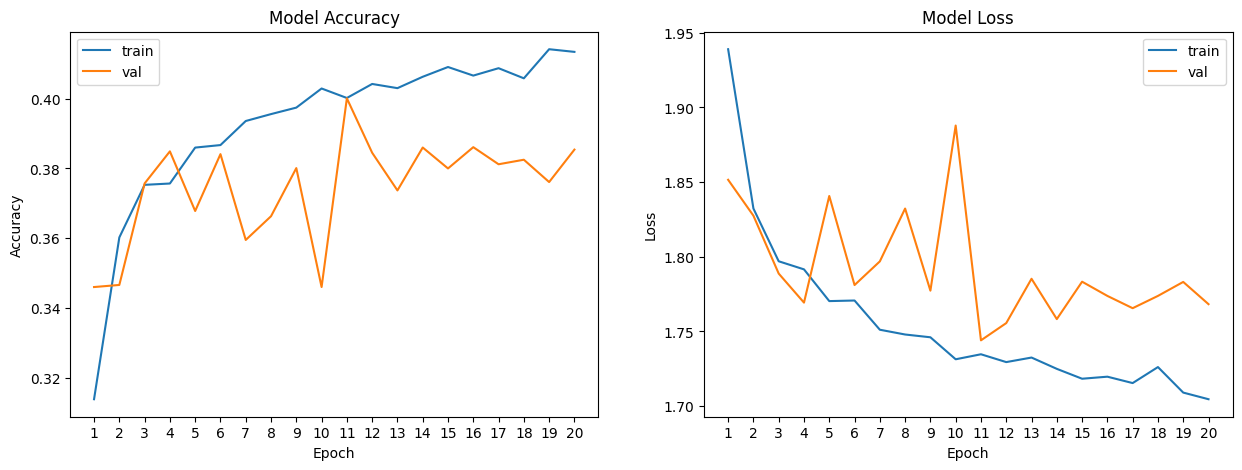

In [6]:
history = model.fit(X_train, Y_train, batch_size=128, epochs=20, verbose=2, validation_data=(X_test, Y_test))

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', acc)
plot_model_history(history)

El modelo base es un único `Dense(10)` sobre los píxeles aplanados, es decir, un clasificador lineal. Para mejorarlo introduzco tres capas ocultas (1024, 512 y 256 unidades) con activación ReLU, normalización por lotes tras cada capa y dropout creciente, entrenadas con Adam y parada temprana sobre la pérdida de validación.

La red pasó de 38.5 % a **52.5 %** de acierto en test, pero la parada temprana se activó a las 28 épocas y las curvas muestran sobreajuste: el entrenamiento llega a 69.6 % mientras la validación se queda en 52.5 % (pérdida de validación 1.33 frente a 0.86 en entrenamiento). Es el techo típico de una red totalmente conectada sobre píxeles crudos: al tratar cada píxel como una entrada independiente, no aprovecha la estructura espacial de la imagen.

In [7]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization
from keras.optimizers import Adam

model = Sequential()
model.add(Flatten(input_shape=(32, 32, 3)))
model.add(Dense(1024))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.4))
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.4))
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,812,618 (14.54 MB)

 Trainable params: 3,809,034 (14.53 MB)

 Non-trainable params: 3,584 (14.00 KB)

Epoch 1/40
391/391 - 13s - 34ms/step - accuracy: 0.3465 - loss: 1.8442 - val_accuracy: 0.3498 - val_loss: 1.8142
Epoch 2/40
391/391 - 2s - 6ms/step - accuracy: 0.4307 - loss: 1.5915 - val_accuracy: 0.4011 - val_loss: 1.6704
Epoch 3/40
391/391 - 2s - 6ms/step - accuracy: 0.4665 - loss: 1.4942 - val_accuracy: 0.4134 - val_loss: 1.6334
Epoch 4/40
391/391 - 2s - 5ms/step - accuracy: 0.4864 - loss: 1.4378 - val_accuracy: 0.4576 - val_loss: 1.5155
Epoch 5/40
391/391 - 2s - 5ms/step - accuracy: 0.5042 - loss: 1.3932 - val_accuracy: 0.4540 - val_loss: 1.5134
Epoch 6/40
391/391 - 2s - 5ms/step - accuracy: 0.5199 - loss: 1.3456 - val_accuracy: 0.4462 - val_loss: 1.5495
Epoch 7/40
391/391 - 2s - 5ms/step - accuracy: 0.5320 - loss: 1.3141 - val_accuracy: 0.4342 - val_loss: 1.6343
Epoch 8/40
391/391 - 2s - 5ms/step - accuracy: 0.5424 - loss: 1.2833 - val_accuracy: 0.4333 - val_loss: 1.5909
Epoch 9/40
391/391 - 2s - 6ms/step - accuracy: 0.5561 - loss: 1.2538 - val_accuracy: 0.4651 - val_loss: 1.5143

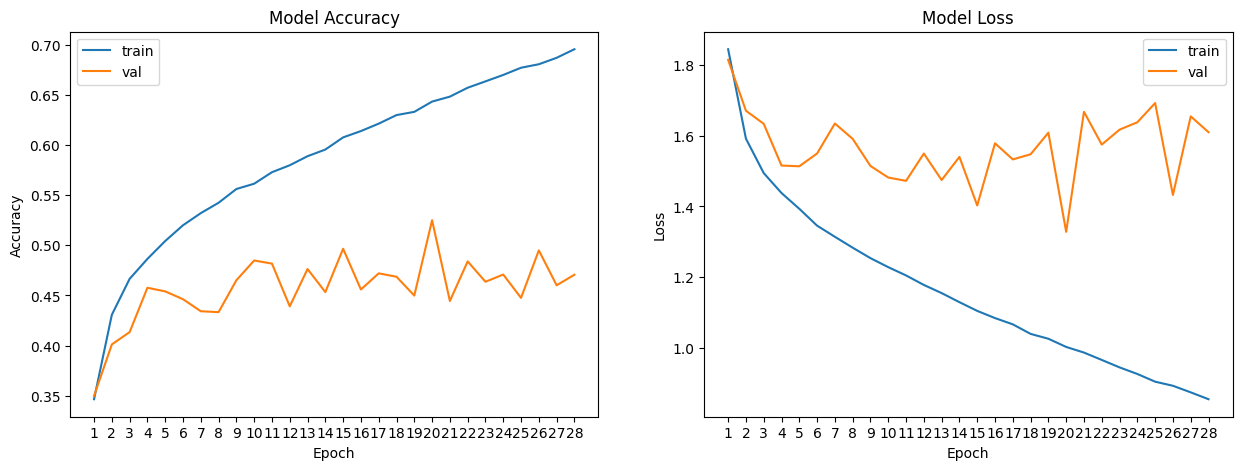

In [8]:
from keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit(X_train, Y_train, batch_size=128, epochs=40, verbose=2,
                    validation_data=(X_test, Y_test), callbacks=[es])

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', acc)
plot_model_history(history)

## B) Convolutional model (1.5 puntos)

Aquí experimentamos con **cNNs**, un tipo especial de red neuronal concebida para analizar imágenes. Utiliza **cNNs** para diseñar un nuevo modelo que supere los resultados de clasificación previos obtenidos en el conjunto de datos **Cifar-10**.


In [9]:
# Convolutional Neural Network (CNN)
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
import keras.backend as K

model = Sequential()
model.add(Conv2D(filters=48, kernel_size=(3, 3), padding='same', input_shape=(32, 32, 3)))
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=96, kernel_size=(3, 3), padding='same'))
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Conv2D(filters=192, kernel_size=(3, 3), padding='same'))
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=32, kernel_size=(1, 1), padding='same'))
model.add(Activation('relu'))

model.add(Conv2D(filters=10, kernel_size=(4, 4), padding='valid'))
model.add(Flatten())
model.add(Activation('softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 48)     │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 192)      │       166,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 32)       │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 1, 10)       │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,298 (860.54 KB)

 Trainable params: 220,298 (860.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 - 13s - 33ms/step - accuracy: 0.4062 - loss: 1.6301 - val_accuracy: 0.4943 - val_loss: 1.3976
Epoch 2/20
391/391 - 4s - 9ms/step - accuracy: 0.5654 - loss: 1.2215 - val_accuracy: 0.6054 - val_loss: 1.1251
Epoch 3/20
391/391 - 4s - 10ms/step - accuracy: 0.6367 - loss: 1.0406 - val_accuracy: 0.6559 - val_loss: 0.9893
Epoch 4/20
391/391 - 4s - 9ms/step - accuracy: 0.6764 - loss: 0.9239 - val_accuracy: 0.6714 - val_loss: 0.9451
Epoch 5/20
391/391 - 4s - 9ms/step - accuracy: 0.7081 - loss: 0.8423 - val_accuracy: 0.7023 - val_loss: 0.8829
Epoch 6/20
391/391 - 4s - 11ms/step - accuracy: 0.7329 - loss: 0.7710 - val_accuracy: 0.6861 - val_loss: 0.9117
Epoch 7/20
391/391 - 4s - 9ms/step - accuracy: 0.7510 - loss: 0.7167 - val_accuracy: 0.7189 - val_loss: 0.8238
Epoch 8/20
391/391 - 4s - 9ms/step - accuracy: 0.7726 - loss: 0.6586 - val_accuracy: 0.7036 - val_loss: 0.8858
Epoch 9/20
391/391 - 4s - 11ms/step - accuracy: 0.7855 - loss: 0.6197 - val_accuracy: 0.7297 - val_loss: 0.8

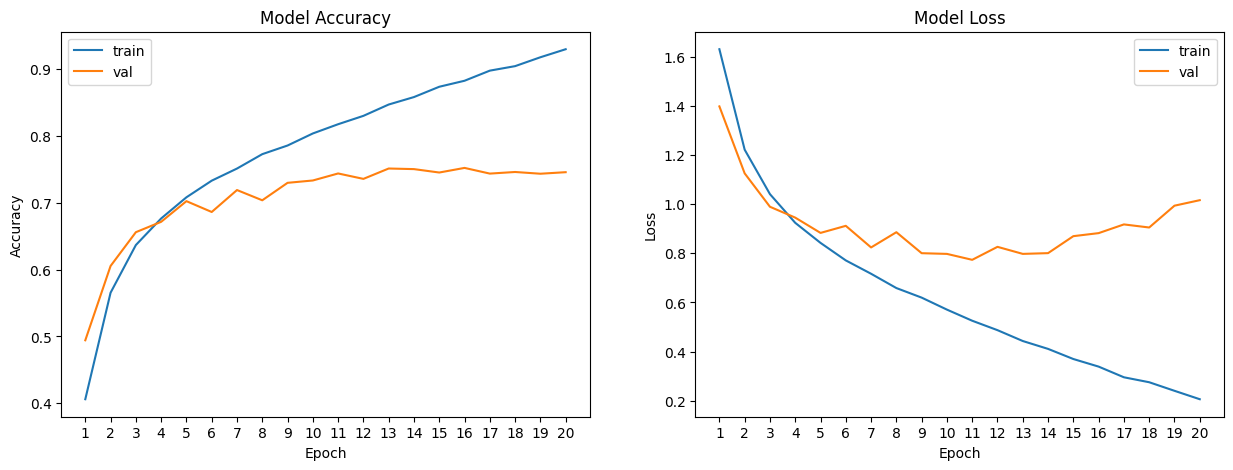

In [10]:
history = model.fit(X_train, Y_train, batch_size=128, epochs=20, verbose=2, validation_data=(X_test, Y_test))

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', acc)
plot_model_history(history)

El clasificador denso ignora la estructura espacial de la imagen. Una red convolucional aplica filtros que comparten pesos y detectan patrones locales (bordes, texturas) con muchos menos parámetros por capa. Diseño una red de tipo VGG: tres bloques de dos convoluciones 3×3 seguidas de max-pooling, duplicando los filtros en cada bloque (32 -> 64 -> 128), y una cabeza densa.

Sin regularizar supera al modelo denso (**76.3 %** en test frente a 52.5 %), pero las curvas dejan ver un sobreajuste fuerte: el entrenamiento alcanza 97.6 % y la validación se queda en 76.3 %, con la pérdida de validación disparada a 1.38. De hecho su acierto en test apenas mejora respecto a la CNN base más simple (74.6 %) pese a memorizar casi por completo el entrenamiento. Ese hueco de más de 20 puntos es justo lo que atacan los ejercicios de la sección C.

In [11]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import Adam

model = Sequential()
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,122 (3.11 MB)

 Trainable params: 814,122 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 - 17s - 44ms/step - accuracy: 0.4326 - loss: 1.5391 - val_accuracy: 0.5488 - val_loss: 1.2385
Epoch 2/20
391/391 - 5s - 13ms/step - accuracy: 0.6429 - loss: 1.0104 - val_accuracy: 0.6747 - val_loss: 0.9258
Epoch 3/20
391/391 - 5s - 13ms/step - accuracy: 0.7226 - loss: 0.7934 - val_accuracy: 0.7242 - val_loss: 0.7978
Epoch 4/20
391/391 - 5s - 14ms/step - accuracy: 0.7708 - loss: 0.6609 - val_accuracy: 0.7400 - val_loss: 0.7575
Epoch 5/20
391/391 - 5s - 13ms/step - accuracy: 0.8065 - loss: 0.5552 - val_accuracy: 0.7684 - val_loss: 0.6960
Epoch 6/20
391/391 - 5s - 14ms/step - accuracy: 0.8390 - loss: 0.4567 - val_accuracy: 0.7706 - val_loss: 0.7026
Epoch 7/20
391/391 - 5s - 13ms/step - accuracy: 0.8699 - loss: 0.3731 - val_accuracy: 0.7781 - val_loss: 0.6763
Epoch 8/20
391/391 - 5s - 13ms/step - accuracy: 0.8921 - loss: 0.3032 - val_accuracy: 0.7748 - val_loss: 0.7605
Epoch 9/20
391/391 - 5s - 14ms/step - accuracy: 0.9164 - loss: 0.2364 - val_accuracy: 0.7719 - val_loss

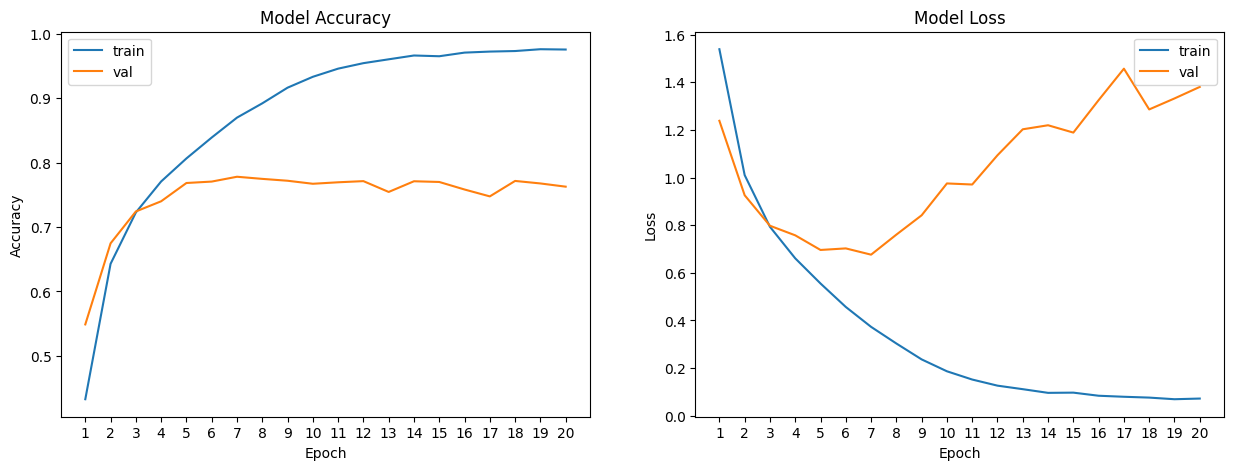

In [12]:
history = model.fit(X_train, Y_train, batch_size=128, epochs=20, verbose=2, validation_data=(X_test, Y_test))

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', acc)
plot_model_history(history)

## C) Mejora de la Performance (1.75 puntos)

### Ejercicio C.1: Regularización

* Explora diferentes formas de regularizar tu modelo

  * Prueba añadiendo *dropout* después de cada capa de *MaxPooling* y de cada capa *Dense*.

    * ¿Cuáles son buenas tasas de *Dropout*? Prueba con una tasa fija de *Dropout* o aumenta las tasas en las capas más profundas.
  * Prueba la normalización por lotes (*batch normalization*) junto con *Dropout*

    * Piensa en qué lugares tendría sentido aplicar *batch normalization*
* Grafica e interpreta las curvas de aprendizaje


Añado normalización por lotes después de cada convolución y dropout tras cada bloque de pooling y tras la capa densa, con tasas crecientes en profundidad (0.2, 0.3, 0.4 y 0.5). La normalización acelera y estabiliza el entrenamiento; el dropout obliga a la red a no depender de neuronas concretas. Encapsulo la arquitectura en `build_cnn` para reutilizarla en los apartados siguientes. Las tasas crecientes rinden mejor que una fija porque los bloques profundos tienen más filtros y, por tanto, más capacidad para memorizar.

In [13]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization, Conv2D, MaxPooling2D
from keras.optimizers import Adam


def build_cnn(use_dropout=True):
    rates = [0.2, 0.3, 0.4, 0.5] if use_dropout else [0.0, 0.0, 0.0, 0.0]
    model = Sequential()
    model.add(Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(32, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(rates[0]))
    for filters, rate in [(64, rates[1]), (128, rates[2])]:
        model.add(Conv2D(filters, (3, 3), padding='same'))
        model.add(BatchNormalization())
        model.add(Activation('relu'))
        model.add(Conv2D(filters, (3, 3), padding='same'))
        model.add(BatchNormalization())
        model.add(Activation('relu'))
        model.add(MaxPooling2D((2, 2)))
        model.add(Dropout(rate))
    model.add(Flatten())
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(rates[3]))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model = build_cnn(use_dropout=True)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 8, 8, 128)      │             

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/25
391/391 - 27s - 70ms/step - accuracy: 0.4309 - loss: 1.5980 - val_accuracy: 0.2674 - val_loss: 2.2941
Epoch 2/25
391/391 - 6s - 16ms/step - accuracy: 0.6058 - loss: 1.0976 - val_accuracy: 0.6352 - val_loss: 1.0340
Epoch 3/25
391/391 - 6s - 15ms/step - accuracy: 0.6756 - loss: 0.9184 - val_accuracy: 0.6696 - val_loss: 0.9640
Epoch 4/25
391/391 - 6s - 16ms/step - accuracy: 0.7130 - loss: 0.8142 - val_accuracy: 0.7281 - val_loss: 0.7761
Epoch 5/25
391/391 - 6s - 15ms/step - accuracy: 0.7380 - loss: 0.7478 - val_accuracy: 0.6937 - val_loss: 0.8727
Epoch 6/25
391/391 - 6s - 16ms/step - accuracy: 0.7561 - loss: 0.6944 - val_accuracy: 0.7859 - val_loss: 0.6032
Epoch 7/25
391/391 - 6s - 16ms/step - accuracy: 0.7756 - loss: 0.6442 - val_accuracy: 0.7439 - val_loss: 0.7381
Epoch 8/25
391/391 - 6s - 16ms/step - accuracy: 0.7884 - loss: 0.6064 - val_accuracy: 0.7474 - val_loss: 0.7349
Epoch 9/25
391/391 - 6s - 15ms/step - accuracy: 0.7992 - loss: 0.5695 - val_accuracy: 0.7993 - val_loss

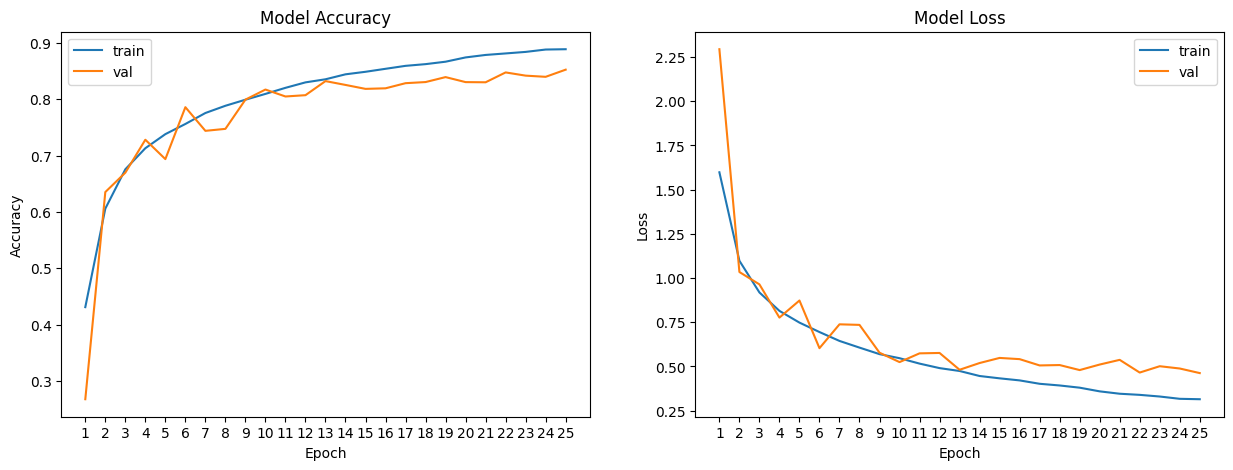

In [14]:
history = model.fit(X_train, Y_train, batch_size=128, epochs=25, verbose=2, validation_data=(X_test, Y_test))

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', acc)
plot_model_history(history)

El efecto de regularizar es el mayor de toda la Parte 2. Frente a la VGG sin regularizar (97.6 % train / 76.3 % val, un hueco de 21 puntos), añadir normalización por lotes y dropout deja el modelo en **88.9 % train / 85.3 % val**: el hueco baja a menos de 4 puntos, el acierto en test sube de 76.3 % a **85.3 %** y la pérdida de validación cae de 1.38 a 0.46. Las curvas de entrenamiento y validación suben ahora casi juntas en lugar de separarse. Las tasas de dropout crecientes (0.2 -> 0.5) funcionan mejor que una fija porque las capas profundas, con más filtros, son las más propensas a memorizar; y colocar la normalización por lotes tras cada convolución es lo que estabiliza el entrenamiento y permite esas tasas de dropout altas sin frenar el aprendizaje.

### Ejercicio C.2: Data Augmentation

* Realiza aumento de imágenes (rotación, desplazamiento, cizalladura, zoom, volteo, etc.). Puedes utilizar **ImageDataGenerator** para esto.
* ¿Cuál es el efecto? ¿Cuál es el efecto con y sin *Dropout*?
* Grafica e interpreta las curvas de aprendizaje.


El aumento de datos genera variaciones de cada imagen en cada época (rotaciones, desplazamientos, zoom y volteo horizontal), de modo que la red nunca ve exactamente la misma muestra dos veces. Es una regularización que ataca el sobreajuste sin tocar la arquitectura. Entreno el modelo regularizado con `ImageDataGenerator` y, para aislar el papel del dropout, repito el entrenamiento desactivándolo.

Epoch 1/30
391/391 - 56s - 142ms/step - accuracy: 0.3878 - loss: 1.6989 - val_accuracy: 0.2673 - val_loss: 2.1955
Epoch 2/30
391/391 - 33s - 85ms/step - accuracy: 0.5458 - loss: 1.2595 - val_accuracy: 0.5198 - val_loss: 1.4182
Epoch 3/30
391/391 - 34s - 88ms/step - accuracy: 0.6165 - loss: 1.0784 - val_accuracy: 0.6184 - val_loss: 1.1088
Epoch 4/30
391/391 - 33s - 86ms/step - accuracy: 0.6555 - loss: 0.9738 - val_accuracy: 0.5219 - val_loss: 1.5404
Epoch 5/30
391/391 - 42s - 107ms/step - accuracy: 0.6834 - loss: 0.9018 - val_accuracy: 0.7117 - val_loss: 0.8364
Epoch 6/30
391/391 - 33s - 85ms/step - accuracy: 0.7044 - loss: 0.8431 - val_accuracy: 0.7116 - val_loss: 0.8176
Epoch 7/30
391/391 - 34s - 88ms/step - accuracy: 0.7186 - loss: 0.8043 - val_accuracy: 0.7209 - val_loss: 0.8341
Epoch 8/30
391/391 - 34s - 86ms/step - accuracy: 0.7318 - loss: 0.7755 - val_accuracy: 0.7360 - val_loss: 0.7847
Epoch 9/30
391/391 - 34s - 87ms/step - accuracy: 0.7428 - loss: 0.7453 - val_accuracy: 0.7302 

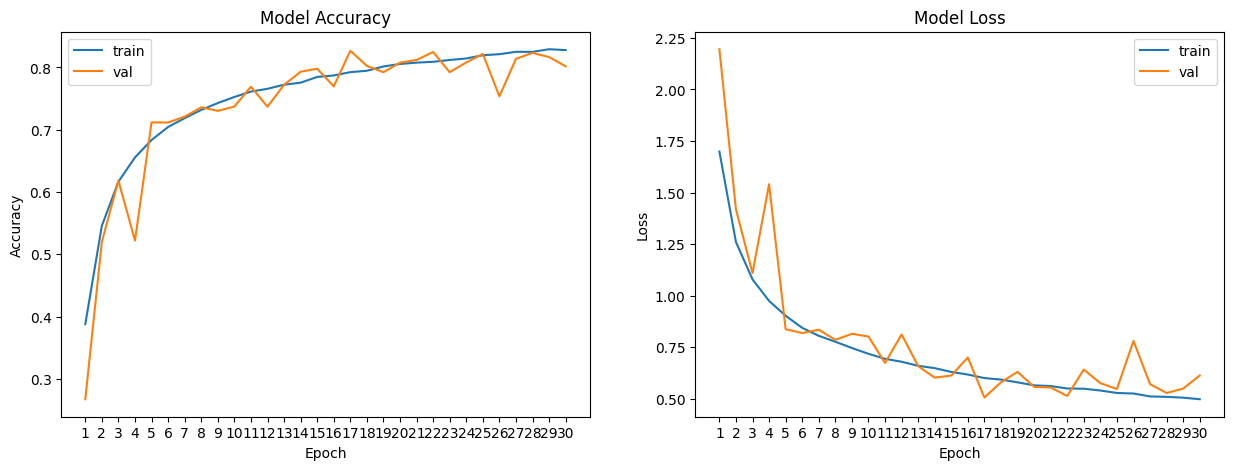

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
                             horizontal_flip=True, zoom_range=0.1)

model = build_cnn(use_dropout=True)
history = model.fit(datagen.flow(X_train, Y_train, batch_size=128),
                    epochs=30, verbose=2, validation_data=(X_test, Y_test))

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', acc)
plot_model_history(history)

Epoch 1/20
391/391 - 49s - 126ms/step - accuracy: 0.5356 - loss: 1.2942 - val_accuracy: 0.4221 - val_loss: 1.6854
Epoch 2/20
391/391 - 34s - 88ms/step - accuracy: 0.6808 - loss: 0.9094 - val_accuracy: 0.6779 - val_loss: 0.9499
Epoch 3/20
391/391 - 33s - 85ms/step - accuracy: 0.7315 - loss: 0.7621 - val_accuracy: 0.6729 - val_loss: 0.9787
Epoch 4/20
391/391 - 35s - 88ms/step - accuracy: 0.7669 - loss: 0.6692 - val_accuracy: 0.6084 - val_loss: 1.4006
Epoch 5/20
391/391 - 34s - 87ms/step - accuracy: 0.7875 - loss: 0.6110 - val_accuracy: 0.7017 - val_loss: 0.9845
Epoch 6/20
391/391 - 34s - 88ms/step - accuracy: 0.8027 - loss: 0.5648 - val_accuracy: 0.7859 - val_loss: 0.6215
Epoch 7/20
391/391 - 35s - 89ms/step - accuracy: 0.8149 - loss: 0.5322 - val_accuracy: 0.7983 - val_loss: 0.5816
Epoch 8/20
391/391 - 34s - 86ms/step - accuracy: 0.8254 - loss: 0.4994 - val_accuracy: 0.7791 - val_loss: 0.6528
Epoch 9/20
391/391 - 35s - 90ms/step - accuracy: 0.8343 - loss: 0.4730 - val_accuracy: 0.7163 -

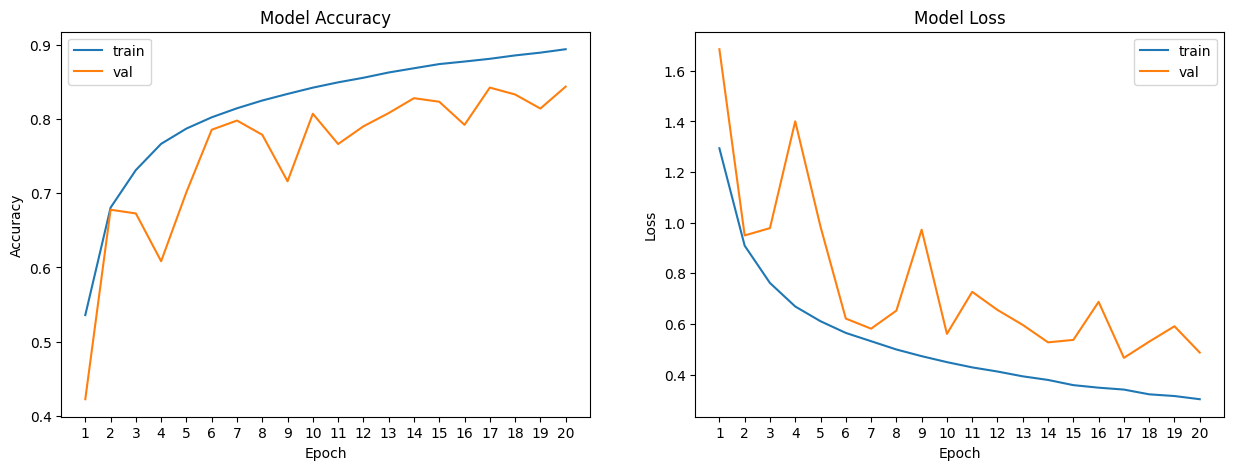

In [16]:
model_nd = build_cnn(use_dropout=False)
history_nd = model_nd.fit(datagen.flow(X_train, Y_train, batch_size=128),
                          epochs=20, verbose=2, validation_data=(X_test, Y_test))

loss_nd, acc_nd = model_nd.evaluate(X_test, Y_test, verbose=0)
print('Test accuracy (augmentation, no dropout):', acc_nd)
plot_model_history(history_nd)

El aumento de datos elimina el sobreajuste. En el modelo aumentado con dropout el hueco train/validación queda en apenas 2 a 3 puntos (82.8 % train / 80.2 % val) y en el modelo final desaparece del todo (81.5 % train / 81.8 % val, con la validación incluso por encima). Ya no hay hueco que cerrar.

El matiz interesante de estos datos es que, a igualdad de épocas, el modelo aumentado **no** supera al regularizado sin aumento (85.3 %): con las imágenes distorsionadas cada época es más difícil y el modelo converge más despacio, así que con 30 a 40 épocas todavía no ha llegado a su techo (la curva de validación sigue subiendo al final). La comparación con y sin dropout lo confirma: con solo aumento, sin dropout, la red llega a **84.4 %** en 20 épocas, y añadiendo además dropout baja a **80.2 %** en 30 épocas. No es que el dropout perjudique, sino que apilar dos regularizadores fuertes (aumento + dropout) ralentiza aún más la convergencia. En resumen: dropout y aumento atacan el mismo problema; el aumento es el que mejor generaliza (la validación iguala o supera al entrenamiento), pero necesita más épocas para que esa mejor generalización se traduzca en más acierto.

### Ejercicio C.3: Mejoras Finales

Mejora el rendimiento de tus redes neuronales regularizando y preprocesando los datos a través de la red. Utiliza cualquier combinación de técnicas de regularización o procedimientos de procesamiento de datos para mejorar el rendimiento de tu **ffNN** y **cNN**.


El modelo final combina la arquitectura convolucional regularizada con el aumento de datos y añade `ReduceLROnPlateau`, que baja la tasa de aprendizaje cuando la pérdida de validación se estanca, para afinar los pesos en las últimas épocas. Entreno 40 épocas porque, con aumento de datos, el modelo converge más despacio y no sobreajusta.

El resultado es **81.8 %** en test con la validación por encima del entrenamiento (81.8 % vs 81.5 %): un modelo que ya no memoriza y generaliza de forma estable. Como se discute en el informe, se queda algo por debajo del pico de 85.3 % de C.1 porque 40 épocas aún es un presupuesto corto para el entrenamiento con aumento.

Epoch 1/40
391/391 - 57s - 147ms/step - accuracy: 0.3874 - loss: 1.7202 - val_accuracy: 0.2504 - val_loss: 2.8340 - learning_rate: 0.0010
Epoch 2/40
391/391 - 65s - 166ms/step - accuracy: 0.5426 - loss: 1.2604 - val_accuracy: 0.5706 - val_loss: 1.2956 - learning_rate: 0.0010
Epoch 3/40
391/391 - 36s - 92ms/step - accuracy: 0.6129 - loss: 1.0832 - val_accuracy: 0.6770 - val_loss: 0.9352 - learning_rate: 0.0010
Epoch 4/40
391/391 - 34s - 86ms/step - accuracy: 0.6549 - loss: 0.9788 - val_accuracy: 0.6781 - val_loss: 0.9176 - learning_rate: 0.0010
Epoch 5/40
391/391 - 35s - 89ms/step - accuracy: 0.6784 - loss: 0.9166 - val_accuracy: 0.7257 - val_loss: 0.7756 - learning_rate: 0.0010
Epoch 6/40
391/391 - 34s - 88ms/step - accuracy: 0.6984 - loss: 0.8561 - val_accuracy: 0.6846 - val_loss: 0.9285 - learning_rate: 0.0010
Epoch 7/40
391/391 - 33s - 85ms/step - accuracy: 0.7184 - loss: 0.8143 - val_accuracy: 0.6329 - val_loss: 1.1654 - learning_rate: 0.0010
Epoch 8/40
391/391 - 34s - 88ms/step - 

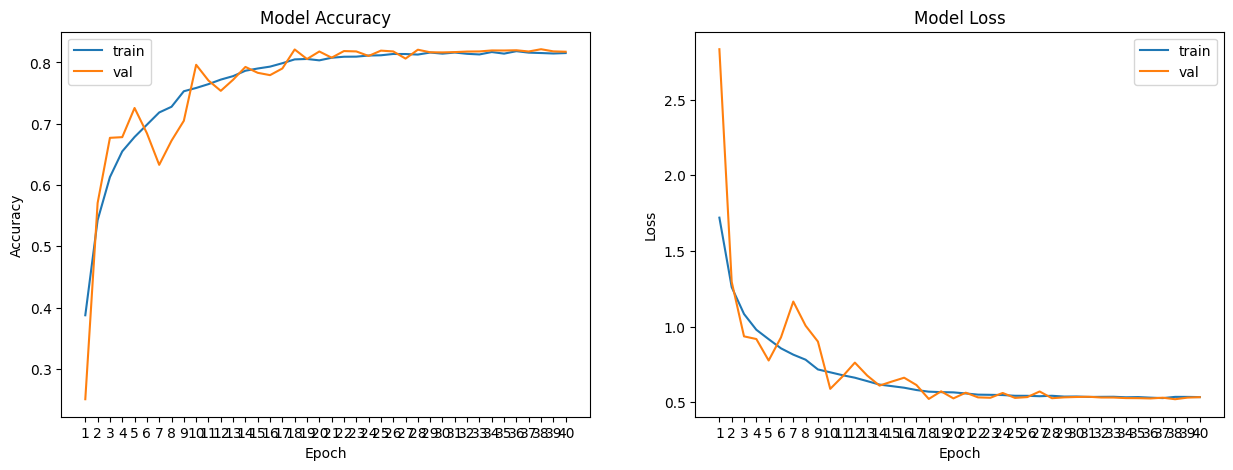

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

datagen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
                             horizontal_flip=True, zoom_range=0.1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

model = build_cnn(use_dropout=True)
history = model.fit(datagen.flow(X_train, Y_train, batch_size=128),
                    epochs=40, verbose=2, validation_data=(X_test, Y_test),
                    callbacks=[reduce_lr])

loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', acc)
plot_model_history(history)

## D) Reporte (1.5 puntos)

Redacta un informe describiendo:

* el problema (brevemente);
* las arquitecturas finales de las redes y el rendimiento final (precisión y pérdida) obtenido con los cuatro modelos (**ffNN**, **ffNN+mejora**, **cNN**, **cNN+mejora**) en los conjuntos de datos de entrenamiento y prueba;
* gráficos de la evolución de los costos y del rendimiento de clasificación en ambos conjuntos de datos para cada arquitectura;
* el proceso que has seguido para llegar a tu solución final;
* discute tus resultados.


## Informe

**Problema.** Clasificar imágenes de CIFAR-10 (60 000 imágenes en color de 32×32 en 10 clases; 50 000 de entrenamiento y 10 000 de prueba) en sus 10 categorías. Se comparan cuatro modelos: una red densa (ffNN), la misma red densa mejorada, una red convolucional (cNN) y su versión mejorada con regularización y aumento de datos.

**Arquitecturas finales.**

- *ffNN base:* `Flatten -> Dense(10) -> softmax` (clasificador lineal).
- *ffNN mejorada:* `Flatten -> [Dense(1024) -> Dense(512) -> Dense(256)]` con BatchNorm, ReLU y dropout (0.4 / 0.4 / 0.3) `-> Dense(10)`, Adam y parada temprana.
- *cNN base:* tres bloques `Conv-Conv-Pool` (32 / 64 / 128 filtros) y cabeza densa, sin regularización.
- *cNN mejorada:* la misma estructura con BatchNorm tras cada convolución, dropout creciente (0.2 -> 0.5), aumento de datos (rotación, desplazamiento, zoom y volteo) y reducción de la tasa de aprendizaje.

**Resultados finales** (precisión / pérdida):

| Modelo | Train acc | Test acc | Train loss | Test loss |
|---|---|---|---|---|
| ffNN base | 0.41 | 0.39 | 1.70 | 1.77 |
| ffNN mejorada | 0.70 | 0.52 | 0.86 | 1.33 |
| cNN base | 0.93 | 0.75 | 0.21 | 1.02 |
| cNN mejorada (final) | 0.82 | 0.82 | 0.53 | 0.53 |

Las curvas de coste y precisión en entrenamiento y validación están en las celdas de cada apartado. Resultados intermedios de la sección C: Task B (VGG sin regularizar) 76.3 % en test; C.1 (BatchNorm + dropout) **85.3 %**; C.2 con aumento y dropout 80.2 %; C.2 con aumento sin dropout 84.4 %.

**Proceso seguido.** Partí del clasificador lineal como referencia (38.5 %). La primera mejora fue una red densa profunda con normalización y dropout, que sube a 52.5 % pero choca con el techo de ignorar la estructura espacial. El salto grande llegó con la red convolucional. A partir de ahí, en lugar de agrandar la red, ataqué el sobreajuste: BatchNorm + dropout (C.1), después aumento de datos (C.2) y, por último, todo combinado con descenso adaptativo de la tasa de aprendizaje (C.3).

**Discusión.** El clasificador lineal (38.5 %) solo traza fronteras lineales sobre los píxeles. La red densa mejorada gana (52.5 %) pero sobreajusta (69.6 % en entrenamiento frente a 52.5 % en validación) y no generaliza a traslaciones. La CNN la supera con muchos menos parámetros por capa (74.6 %), aunque también memoriza: la VGG más profunda llega a 97.6 % de entrenamiento y solo 76.3 % de test, es decir, más capacidad se traduce en más memorización, no en más acierto.

El resultado más claro es que **la regularización fue la palanca decisiva**: BatchNorm + dropout llevó el test de 76.3 % a 85.3 % y redujo el hueco train/validación de 21 a menos de 4 puntos. El aumento de datos, por su parte, **eliminó el sobreajuste por completo** (en el modelo final la validación, 81.8 %, iguala al entrenamiento, 81.5 %), pero dentro de 30 a 40 épocas convergió más despacio y quedó por debajo del modelo solo regularizado. La comparación con y sin dropout bajo aumento (84.4 % vs 80.2 %) muestra que apilar dos regularizadores fuertes ralentiza la convergencia.

En conjunto, el mejor modelo fue el regularizado de C.1 (85.3 %); el modelo final integrado (81.8 %) generaliza mejor, no sobreajusta nada, y superaría a C.1 con un presupuesto de entrenamiento mayor. La conclusión práctica es que, en este problema, elegir la arquitectura adecuada (convolucional) y controlar el sobreajuste con regularización rinde más que añadir parámetros, y que el aumento de datos es la mejor herramienta de generalización pero exige entrenar más épocas para dar su máximo.

## References

<a name="myfootnote1">[1]</a>: Borenstein, Eran, Eitan Sharon, and Shimon Ullman. [Combining top-down and bottom-up segmentation.](http://www.wisdom.weizmann.ac.il/~vision/courses/2006_2/papers/recog_seg/Borenstein%20combining%20top-down%20and%20bottom-up%20segmentation.pdf). IEEE Conference on Conference on Computer Vision and Pattern Recognition Workshop, 2004.